# 多层感知机

## 隐藏层

线性意味着单调假设，任何特征的增大都会导致模型输出的增大（权重为正），而且一些实际问题上（猫狗分类）线性假设是完全不合理的

### 在网络中加入隐藏层

通过在网络中加入一个或者多个隐藏层来克服线性模型的限制


最简单的方法是：把许多的全连接层堆叠在一起，每一层都输出到上面的层，直到生成最后的输出层；这样前$L-1$层看做表示层，最后一层看做线性预测器，这种架构称为多层感知机

### 从线性到非线性

通过矩阵 $X \in \mathbb{R}^{n \times d}$ 来表示n个样本的小批量，其中每个样本具有d个输入特征；

对于具有h个隐藏单元的单隐藏层多层感知机，用$ H \in \mathbb{R}^{n \times h}$ 来表示隐藏层的输出,称为隐藏表示；

因为隐藏层和输出层都是全连接的，所以我们有：

隐藏层权重$ W^{(1)} \in \mathbb{R}^{d \times h} $和偏置$ b^{(1)} \in \mathbb{R}^{1 \times h} $，输出层权重$ W^{(2)} \in \mathbb{R}^{h \times q} $和偏置$ b^{(2)} \in \mathbb{R}^{1 \times q} $，满足：


$$ H = X W^{(1)} + b^{(1)} $$
$$ O = H W^{(2)} + b^{(2)} $$

广播机制：沿着行方向广播，将$ b^{(1)} $和$ b^{(2)} $广播到$ H $和$ O $的每个样本上

这里的隐藏单元由输入的仿射函数给出，输出只是隐藏单元的仿射函数，仿射函数的复合依然是仿射函数，下面证明等价性：

$$
O = (X W^{(1)} + b^{(1)}) W^{(2)} + b^{(2)} = XW^{(1)} W^{(2)} + b^{(1)}W^{(2)} + b^{(2)} = XW + b
$$

其中$W = W^{(1)} W^{(2)}, b = b^{(1)}W^{(2)} + b^{(2)}$

为了发挥多层架构的潜力，需要一个激活函数：在仿射变换之后对每个隐藏单元应用非线性的激活函数$\delta$

激活函数的输出值称为活性值，有了激活值，多层感知机就不会退化成线性模型：
$$ H = \delta(X W^{(1)} + b^{(1)}) \\
O = (H W^{(2)} + b^{(2)}) $$


### 通用近似定理

只要拥有至少一个隐藏层，并且该隐藏层包含足够多的神经元，那么引入了非线性激活函数的多层感知机（MLP），就能以任意设定的精度，逼近（拟合）任何一个连续的数学函数。

即只要函数是连续的，神经网络就一定有能力可以把他表示出来

## 激活函数

通过计算加权和并加上偏置来确定神经元是否应该被激活，将输入信号转换为输出的可微运算，下面给一些常见的激活函数：

### Relu

$$
Relu(x) = max(x, 0)
$$

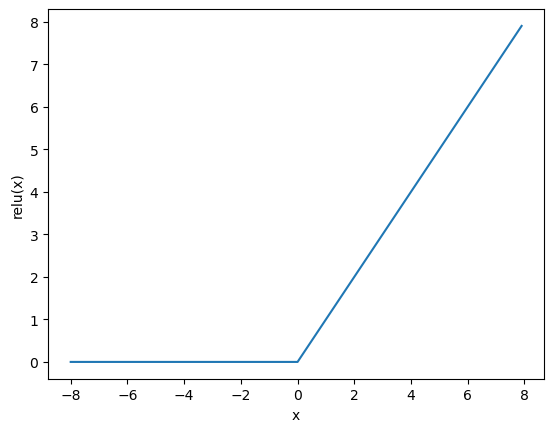

In [2]:
import torch
from matplotlib import pyplot as plt

x = torch.arange(-8.0, 8.0, 0.1,requires_grad=True)
y = torch.relu(x)
plt.plot(x.detach(), y.detach()) # 这里plt的库会自动把torch张量转换为numpy数组，一定要把数值剥离掉计算图，否则会报错
plt.xlabel('x')
plt.ylabel('relu(x)')
plt.show()

下面绘制Relu函数的导数

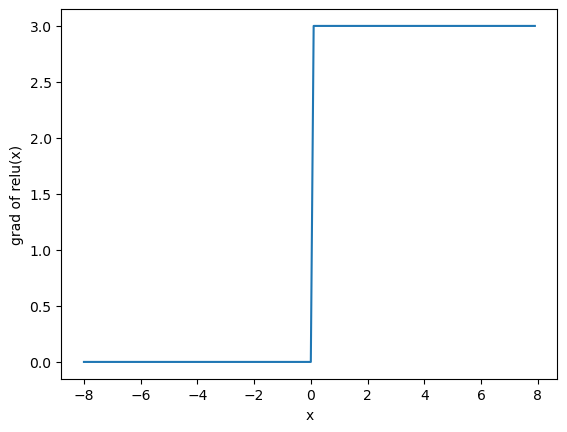

In [5]:
y.backward(torch.ones_like(y), retain_graph=True)  # 这里是pytorch的求导问题，retain操作表示需要保留这次求导运算的结果，不然后面就销毁掉了
# 传入的向量是和雅可比矩阵相乘的
plt.plot(x.detach(), x.grad)  # 梯度不会保存到中间变量y中，默认情况下，反向传播结束后，只保留“叶子节点（x）”的梯度
plt.xlabel('x')
plt.ylabel('grad of relu(x)')
plt.show()

关于backward的说明： 在pytorch的自动求导机制中，默认的是针对一个标量去求向量的导数，直接对向量调用backward方法会报错。
假设 $\mathbf{x} = [x_1, x_2, x_3]$，经过某个函数变成了 $\mathbf{y} = [y_1, y_2, y_3]$。在微积分中，向量对向量求导，得到的是一个矩阵，叫做雅可比矩阵（Jacobian Matrix） $J$：$$J = 
\begin{bmatrix}
\frac{\partial y_1}{\partial x_1} & \frac{\partial y_1}{\partial x_2} & \frac{\partial y_1}{\partial x_3} \\
\frac{\partial y_2}{\partial x_1} & \frac{\partial y_2}{\partial x_2} & \frac{\partial y_2}{\partial x_3} \\
\frac{\partial y_3}{\partial x_1} & \frac{\partial y_3}{\partial x_2} & \frac{\partial y_3}{\partial x_3}
\end{bmatrix}$$PyTorch 为了性能，绝对不会直接去计算并存储这个庞大的矩阵。

相反，它要求你提供一个与 $y$ 形状相同的权重向量 $\mathbf{v}$。PyTorch 底层实际计算的是这个向量与雅可比矩阵的乘积：$\mathbf{v}^T \cdot J$。如果传入的 $\mathbf{v}$ 是一个全 1 向量 [1, 1, 1]，结果是：  $$[1, 1, 1] \cdot J = \left[ \sum_{i=1}^3 \frac{\partial y_i}{\partial x_1}, \quad \sum_{i=1}^3 \frac{\partial y_i}{\partial x_2}, \quad \sum_{i=1}^3 \frac{\partial y_i}{\partial x_3} \right]$$

针对relu函数适配，因为$ \frac{\partial y_2}{\partial x_1} = 0 $。

### sigmoid函数

挤压函数，将范围$(-\infty, \infty)$映射到$(0, 1)$
$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$


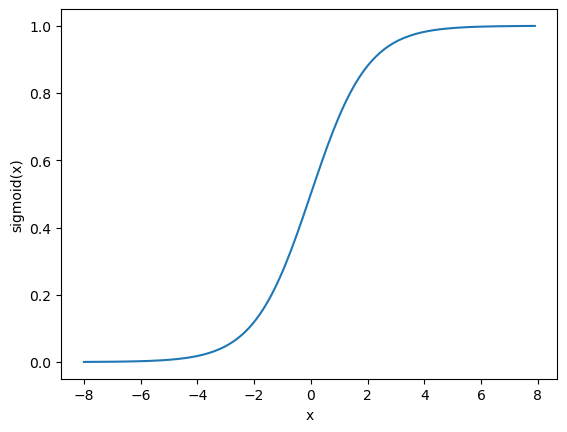

In [6]:
y = torch.sigmoid(x)
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.show()


sigmoid函数的导数公式为：
$$
\frac{d}{dx} sigmoid(x) = \frac{e^{-x}}{(1 + e^{-x})^2} = sigmoid(x)(1 - sigmoid(x))
$$

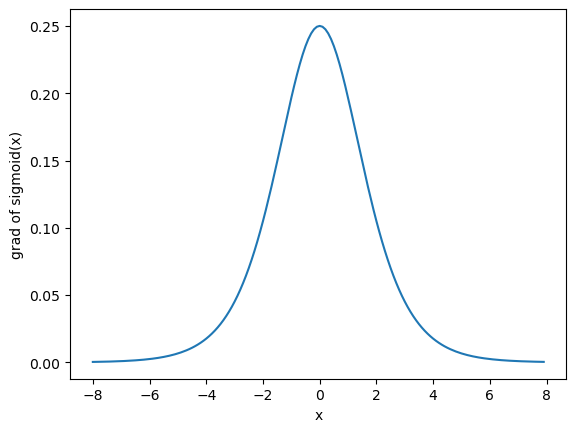

In [7]:
x.grad.data.zero_()
y.backward(torch.ones_like(y), retain_graph=True)
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('grad of sigmoid(x)')
plt.show()

### tanh函数
$$
tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} = \frac{1-e^{(-2x)}}{1+e^{(-2x)}}
$$


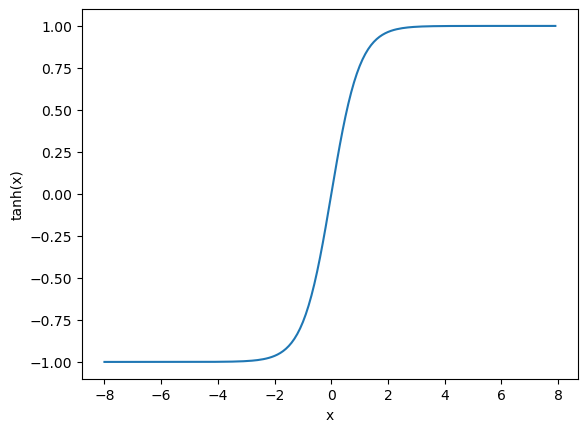

In [9]:
x.grad.data.zero_()
y = torch.tanh(x)
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.show()

导数是这样的：
$$
\frac{d}{dx} tanh(x) = 1 - tanh(x)^2
$$


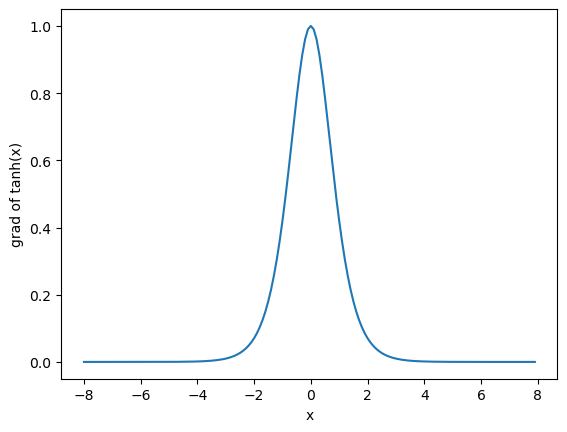

In [10]:
y.backward(torch.ones_like(y), retain_graph=True)
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('grad of tanh(x)')
plt.show()